In [1]:
# Step 1: Import Libraries & Load Data 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Unemployment in India.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Step 2: Data Inspection & Cleaning

print("--- Data Shape----")
print(df.shape)

--- Data Shape----
(768, 7)


In [5]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [6]:
df = df.dropna()

In [7]:
print(df.shape)

(740, 7)


In [8]:
print(df.isnull().sum())

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [9]:
print(df.dtypes)

Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object


In [10]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [11]:
df.columns = df.columns.str.strip()

In [12]:
# Convert 'Date' column to datetime format

df['Date'] = df['Date'].str.strip() # Remove spaces from date strings
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_11272\760117554.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


"""
### Observaton: Region-wise Average Unemployment
Here we calculate the average unemployment rate across different states.
"""

In [14]:
region_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(region_unemp.head())

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64


In [15]:
print(region_unemp)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


"""
### Observation: Time-Series Trend
This line chart shows how the unemployment rate fluctuated over time in three major states: Delhi, Maharashtra, and Uttar Pradesh. We can see a massive spike around April-May 2020 due to the COVID-19 lockdown.
"""

In [16]:
states_to_plot = ['Delhi', 'Maharashtra', 'Uttar Pradesh']
df_states = df[df['Region'].isin(states_to_plot)]

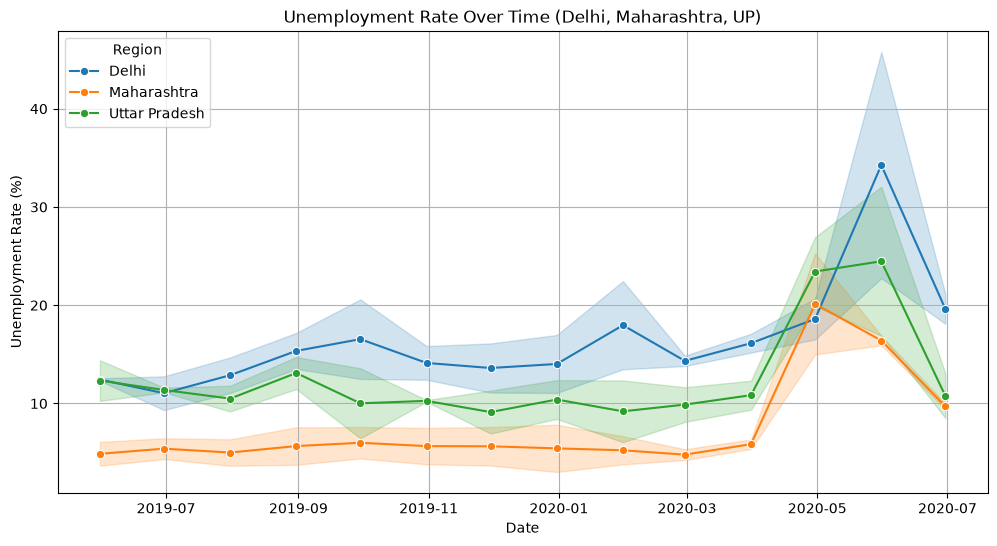

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_states, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title("Unemployment Rate Over Time (Delhi, Maharashtra, UP)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

"""
### Observation: Top 10 States with Highest Unemployment
The bar chart highlights the states that suffered the most on average during the recorded period. Tripura and Haryana consistently show higher rates.
"""

C:\Users\USER\AppData\Local\Temp\ipykernel_11272\3267161951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='Reds_r')


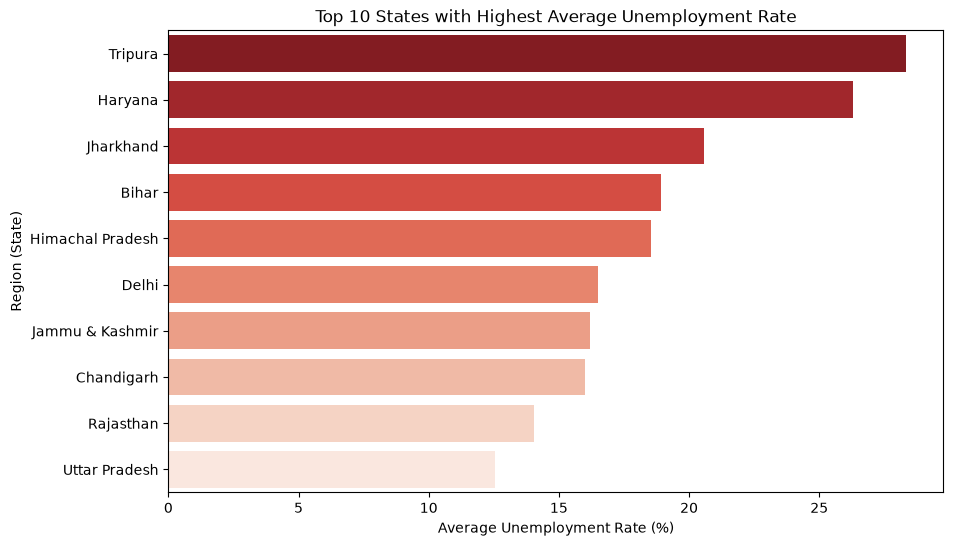

In [18]:
plt.figure(figsize=(10, 6))
top_10 = region_unemp.head(10)
sns.barplot(x=top_10.values, y=top_10.index, palette='Reds_r')
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region (State)")
plt.show()


In [19]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


"""
### Observation: Correlation Heatmap
This heatmap shows the correlation between Unemployment Rate, Employment, and Labour Participation Rate. A strong negative correlation is typically expected between Unemployment and Employment.
"""

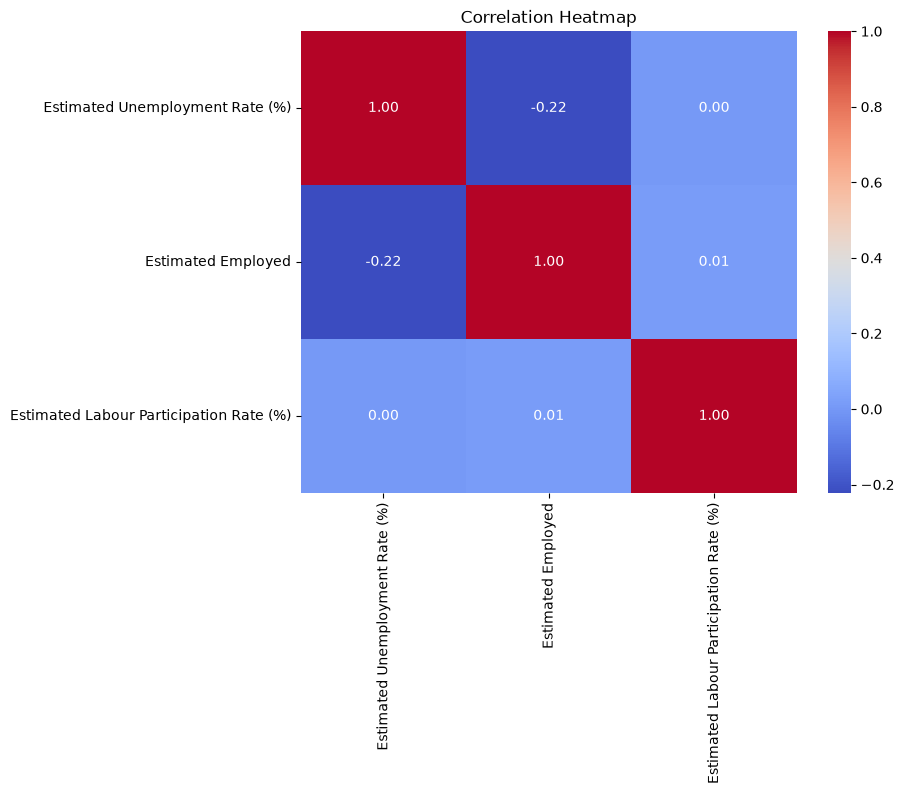

In [20]:
plt.figure(figsize=(8, 6))
cols_for_heatmap = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
correlation_matrix = df[cols_for_heatmap].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

"""
### Observation: Pre-COVID vs Post-COVID Impact
Assuming the national lockdown impact started taking heavily in April 2020. 
We split the data into 'Pre-COVID' (before April 2020) and 'Post/During-COVID' (April 2020 onwards).
The average unemployment rate skyrocketed during the COVID period.
"""

In [21]:
cutoff_date = pd.to_datetime('2020-04-01')

# Split data

pre_covid = df[df['Date']<cutoff_date]
post_covid = df[df['Date']>=cutoff_date]

In [23]:
pre_covid_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Average Unemployment Rate (Pre-COVID): {pre_covid_mean:.2f}%")
print(f"Average Unemployment Rate (During/Post-COVID): {post_covid_mean:.2f}%")

Average Unemployment Rate (Pre-COVID): 9.61%
Average Unemployment Rate (During/Post-COVID): 20.19%


C:\Users\USER\AppData\Local\Temp\ipykernel_11272\669605705.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Pre-COVID', 'During/Post-COVID'], y=[pre_covid_mean, post_covid_mean], palette='viridis')


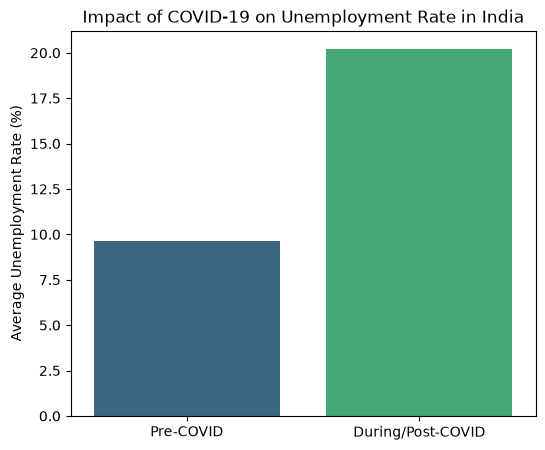

In [24]:
plt.figure(figsize=(6, 5))
sns.barplot(x=['Pre-COVID', 'During/Post-COVID'], y=[pre_covid_mean, post_covid_mean], palette='viridis')
plt.title("Impact of COVID-19 on Unemployment Rate in India")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()